<a href="https://colab.research.google.com/github/muskanbhardwajwork-alt/solar-market-expansion-analysis/blob/main/Solar_Market_Expansion_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Solar Market Expansion Analysis
**Business question:** A residential solar installer wants to know which Australian states to prioritise for expansion.

**Data:** Clean Energy Regulator (CER), *Small-scale installation postcode data* — raw SGU-Solar postcode × month files (installations and capacity, Apr 2001 – Aug 2026). Validated against CER Table 5: *Small generation unit – Solar (deemed)*.
Source: cer.gov.au/markets/reports-and-data/small-scale-installation-postcode-data

**Approach:** Raw data → cleaning & reshaping (Python/pandas) → SQLite database → SQL analysis (CTEs, window functions) → visualisation & forecasting → recommendation.

**Files required in Colab (upload via the Files panel):**
1. `sgu-solar-installations-2001-to-2010.csv`
2. `sgu-solar-installations-2011-to-present-and-totals.csv`
3. `sgu-solar-capacity-2001-to-2010.csv`
4. `sgu-solar-capacity-2011-to-present-and-totals.csv`
5. `solar_installs_by_state.csv` (CER Table 5, transcribed — used for validation only)

## 1. Setup

In [16]:
import re
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

STATES = ['ACT', 'NSW', 'NT', 'QLD', 'SA', 'TAS', 'VIC', 'WA']

## 2. Load raw data
The CER files are wide: one row per postcode, one column per month. Some numeric columns contain thousands separators ("4,446"), so `thousands=','` converts them to numbers on load.

In [17]:
inst_early = pd.read_csv('sgu-solar-installations-2001-to-2010.csv', thousands=',')
inst_late  = pd.read_csv('sgu-solar-installations-2011-to-present-and-totals.csv', thousands=',')
cap_early  = pd.read_csv('sgu-solar-capacity-2001-to-2010.csv', thousands=',')
cap_late   = pd.read_csv('sgu-solar-capacity-2011-to-present-and-totals.csv', thousands=',')

for name, df in [('Installs 2001–2010', inst_early), ('Installs 2011–present', inst_late),
                 ('Capacity 2001–2010', cap_early), ('Capacity 2011–present', cap_late)]:
    print(f"{name}: {df.shape[0]} postcodes x {df.shape[1]} columns")

Installs 2001–2010: 2809 postcodes x 118 columns
Installs 2011–present: 2811 postcodes x 191 columns
Capacity 2001–2010: 2809 postcodes x 118 columns
Capacity 2011–present: 2811 postcodes x 191 columns


## 3. Reshape wide → long and combine periods
Only monthly columns are kept; the files' own total columns are dropped so every figure is rebuilt from the monthly records.

In [3]:
def to_long(df, keyword, value_name):
    # monthly columns only, e.g. "Jan 2011 - Installation Quantity" (excludes historic/total columns)
    month_cols = [c for c in df.columns if re.match(r'^[A-Z][a-z]{2} \d{4} - ', c) and keyword in c]
    long_df = df.melt(id_vars='Small Unit Installation Postcode', value_vars=month_cols,
                      var_name='month_label', value_name=value_name)
    long_df = long_df.rename(columns={'Small Unit Installation Postcode': 'postcode'})
    long_df['year'] = long_df['month_label'].str.extract(r'(\d{4})').astype(int)
    return long_df

installs = pd.concat([to_long(inst_early, 'Install', 'installs'),
                      to_long(inst_late,  'Install', 'installs')], ignore_index=True)
capacity = pd.concat([to_long(cap_early, 'Output', 'capacity_kw'),
                      to_long(cap_late,  'Output', 'capacity_kw')], ignore_index=True)

print("Installation records:", len(installs), "| years", installs['year'].min(), "–", installs['year'].max())
print("Capacity records:", len(capacity), "| years", capacity['year'].min(), "–", capacity['year'].max())
print("Missing values:", installs['installs'].isna().sum(), "/", capacity['capacity_kw'].isna().sum())

Installation records: 857121 | years 2001 – 2026
Capacity records: 857121 | years 2001 – 2026
Missing values: 0 / 0


## 4. Map postcode → state
Two data-quality issues handled here:
- **Leading zeros lost:** NT postcodes (e.g. 0800) are stored as numbers (800), so mapping uses numeric ranges.
- **ACT inside NSW's range:** ACT postcodes (2600–2618, 2900–2920) sit within NSW's 2xxx block and are checked first.

In [4]:
def postcode_to_state(p):
    if p == 0: return 'UNKNOWN'
    if 200 <= p <= 299 or 2600 <= p <= 2618 or 2900 <= p <= 2920: return 'ACT'
    if 800 <= p <= 999: return 'NT'
    if 1000 <= p <= 2999: return 'NSW'
    if 3000 <= p <= 3999 or 8000 <= p <= 8999: return 'VIC'
    if 4000 <= p <= 4999 or 9000 <= p <= 9999: return 'QLD'
    if 5000 <= p <= 5999: return 'SA'
    if 6000 <= p <= 6999: return 'WA'
    if 7000 <= p <= 7999: return 'TAS'
    return 'UNKNOWN'

installs['state'] = installs['postcode'].apply(postcode_to_state)
capacity['state'] = capacity['postcode'].apply(postcode_to_state)

installs.groupby('state')['installs'].sum().sort_values(ascending=False)

,installs
state,
QLD,1220360
NSW,1191166
VIC,906684
WA,585226
SA,466039
ACT,68762
TAS,67926
NT,26011
UNKNOWN,4


## 5. Aggregate to state × year and validate against CER Table 5
If the pipeline is correct, national totals should match the CER's published table exactly.

In [5]:
wide = installs.pivot_table(index='year', columns='state', values='installs', aggfunc='sum', fill_value=0)
wide['total'] = installs.groupby('year')['installs'].sum()
wide = wide[STATES + ['total']].reset_index()

table5 = pd.read_csv('solar_installs_by_state.csv').set_index('year')
built = wide.set_index('year')

print("National totals matching Table 5:", (built['total'] == table5['total']).sum(), "of", len(built), "years")
diff_pct = (built[STATES] - table5[STATES]).abs() / table5[STATES].where(table5[STATES] > 0) * 100
print("\nLargest state-level variance vs Table 5, 2010 onwards (%):")
print(diff_pct.loc[2010:].max().round(2).to_string())

National totals matching Table 5: 26 of 26 years

Largest state-level variance vs Table 5, 2010 onwards (%):
state
ACT    0.57
NSW    0.19
NT     0.28
QLD    0.02
SA     0.02
TAS    0.00
VIC    0.16
WA     0.00


**Validation result:** national totals match in every year. State-level variance is below 0.6%, with NSW slightly under and neighbouring states slightly over — consistent with cross-border postcodes being allocated by install address in the CER's table but by postcode range here (a likely explanation, not confirmed).

## 6. Load into SQLite

In [6]:
conn = sqlite3.connect('solar_installs.db')
cur = conn.cursor()

cur.execute("DROP TABLE IF EXISTS installs_wide")
wide.to_sql('installs_wide', conn, index=False)
print("Rows loaded:", cur.execute("SELECT COUNT(*) FROM installs_wide").fetchone()[0])

Rows loaded: 26


## 7. Reshape to long format in SQL and run quality checks
SQLite has no UNPIVOT, so `UNION ALL` stacks the state columns.

In [7]:
cur.execute("DROP TABLE IF EXISTS installs_long")
cur.execute('''
CREATE TABLE installs_long AS
SELECT year, 'ACT' AS state, ACT AS installs FROM installs_wide
UNION ALL SELECT year, 'NSW', NSW FROM installs_wide
UNION ALL SELECT year, 'NT',  NT  FROM installs_wide
UNION ALL SELECT year, 'QLD', QLD FROM installs_wide
UNION ALL SELECT year, 'SA',  SA  FROM installs_wide
UNION ALL SELECT year, 'TAS', TAS FROM installs_wide
UNION ALL SELECT year, 'VIC', VIC FROM installs_wide
UNION ALL SELECT year, 'WA',  WA  FROM installs_wide
''')
conn.commit()

print("Long-format rows:", cur.execute("SELECT COUNT(*) FROM installs_long").fetchone()[0])
print("Null/negative values:", cur.execute("SELECT COUNT(*) FROM installs_long WHERE installs IS NULL OR installs < 0").fetchone()[0])
mismatch = cur.execute('''
SELECT w.year, w.total - SUM(l.installs) AS gap
FROM installs_wide w JOIN installs_long l ON w.year = l.year
GROUP BY w.year HAVING gap != 0
''').fetchall()
print("Years where state sum != total (unknown-postcode installs):", mismatch)

Long-format rows: 208
Null/negative values: 0
Years where state sum != total (unknown-postcode installs): [(2002, 2), (2004, 1), (2005, 1)]


## 8. Year-over-year growth (CTE + LAG window function)

In [8]:
cur.execute("DROP TABLE IF EXISTS installs_growth")
cur.execute('''
CREATE TABLE installs_growth AS
WITH prev_year AS (
    SELECT state, year, installs,
           LAG(installs) OVER (PARTITION BY state ORDER BY year) AS prev_installs
    FROM installs_long
)
SELECT state, year, installs, prev_installs,
       ROUND((CAST(installs AS FLOAT) - prev_installs) / prev_installs * 100, 1) AS yoy_growth_pct
FROM prev_year
WHERE prev_installs > 0
''')
conn.commit()

pd.read_sql_query("SELECT * FROM installs_growth WHERE year = 2025 ORDER BY yoy_growth_pct DESC", conn)

,state,year,installs,prev_installs,yoy_growth_pct
0,NT,2025,1091,1071,1.9
1,TAS,2025,5209,5283,-1.4
2,ACT,2025,4418,4780,-7.6
3,VIC,2025,62146,67384,-7.8
4,SA,2025,23677,25759,-8.1
5,QLD,2025,69566,81553,-14.7
6,WA,2025,30273,35591,-14.9
7,NSW,2025,75681,97758,-22.6


## 9. Cumulative installs (saturation proxy) and ranking (SUM OVER, RANK, NTILE)

In [9]:
cur.execute("DROP TABLE IF EXISTS installs_cumulative")
cur.execute('''
CREATE TABLE installs_cumulative AS
SELECT state, year, installs,
       SUM(installs) OVER (PARTITION BY state ORDER BY year
                           ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS cumulative_installs
FROM installs_long
''')

cur.execute("DROP TABLE IF EXISTS state_summary_2025")
cur.execute('''
CREATE TABLE state_summary_2025 AS
SELECT g.state, g.installs AS installs_2025, g.yoy_growth_pct, c.cumulative_installs,
       RANK()   OVER (ORDER BY g.yoy_growth_pct DESC)     AS growth_rank,
       NTILE(3) OVER (ORDER BY c.cumulative_installs ASC) AS saturation_tier
FROM installs_growth g
JOIN installs_cumulative c ON g.state = c.state AND g.year = c.year
WHERE g.year = 2025
''')
conn.commit()

pd.read_sql_query("SELECT * FROM state_summary_2025 ORDER BY growth_rank", conn)

,state,installs_2025,yoy_growth_pct,cumulative_installs,growth_rank,saturation_tier
0,NT,1091,1.9,25286,1,1
1,TAS,5209,-1.4,64405,2,1
2,ACT,4418,-7.6,65329,3,1
3,VIC,62146,-7.8,864377,4,2
4,SA,23677,-8.1,446444,5,2
5,QLD,69566,-14.7,1160652,6,3
6,WA,30273,-14.9,558419,7,2
7,NSW,75681,-22.6,1129628,8,3


## 10. Correcting for scale: two-tier market segmentation
Growth rates alone mislead on a small base, so markets are segmented by absolute volume.

In [10]:
segments = pd.read_sql_query('''
SELECT state, installs_2025, yoy_growth_pct, cumulative_installs,
       CASE WHEN cumulative_installs > 500000 THEN 'High volume, established'
            WHEN cumulative_installs > 100000 THEN 'Mid volume'
            ELSE 'Low volume, early-stage' END AS market_type
FROM state_summary_2025
ORDER BY installs_2025 DESC
''', conn)
segments

,state,installs_2025,yoy_growth_pct,cumulative_installs,market_type
0,NSW,75681,-22.6,1129628,"High volume, established"
1,QLD,69566,-14.7,1160652,"High volume, established"
2,VIC,62146,-7.8,864377,"High volume, established"
3,WA,30273,-14.9,558419,"High volume, established"
4,SA,23677,-8.1,446444,Mid volume
5,TAS,5209,-1.4,64405,"Low volume, early-stage"
6,ACT,4418,-7.6,65329,"Low volume, early-stage"
7,NT,1091,1.9,25286,"Low volume, early-stage"


## 11. Long-term installation trends (2001–2025, partial 2026 excluded)

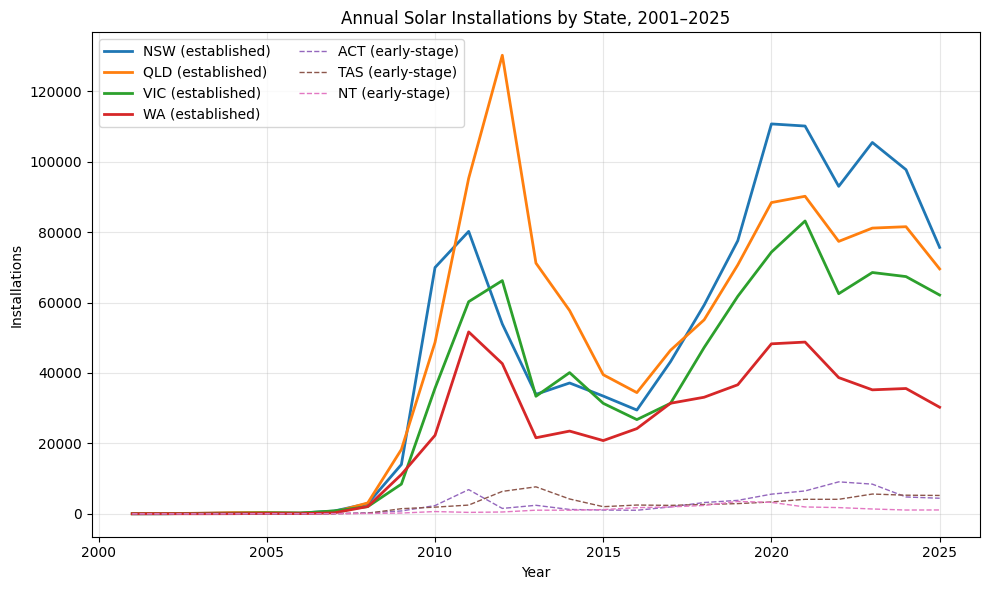

In [11]:
df = pd.read_sql_query("SELECT * FROM installs_long ORDER BY state, year", conn)
full_years = df[df['year'] < 2026]

fig, ax = plt.subplots(figsize=(10, 6))
for s in ['NSW', 'QLD', 'VIC', 'WA']:
    d = full_years[full_years['state'] == s]
    ax.plot(d['year'], d['installs'], linewidth=2, label=f"{s} (established)")
for s in ['ACT', 'TAS', 'NT']:
    d = full_years[full_years['state'] == s]
    ax.plot(d['year'], d['installs'], linewidth=1, linestyle='--', label=f"{s} (early-stage)")
ax.set_title('Annual Solar Installations by State, 2001–2025')
ax.set_xlabel('Year'); ax.set_ylabel('Installations')
ax.legend(ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 12. Forecast: is the 2025 decline structural?
Two independent 2026 estimates for the four largest markets:
1. Linear trend fitted on 2021–2025 (post-peak period)
2. 2026 year-to-date (Jan–Aug) annualised × 12/8

In [12]:
fit = df[(df['year'] >= 2021) & (df['year'] <= 2025)]
rows = []
for s in ['NSW', 'QLD', 'VIC', 'WA']:
    d = fit[fit['state'] == s]
    slope, intercept = np.polyfit(d['year'], d['installs'], 1)
    pred = slope * d['year'] + intercept
    r2 = 1 - ((d['installs'] - pred) ** 2).sum() / ((d['installs'] - d['installs'].mean()) ** 2).sum()
    ytd = df[(df['state'] == s) & (df['year'] == 2026)]['installs'].iloc[0]
    actual_2025 = df[(df['state'] == s) & (df['year'] == 2025)]['installs'].iloc[0]
    rows.append({'state': s, 'actual_2025': actual_2025, 'r_squared': round(r2, 2),
                 'trend_2026': round(slope * 2026 + intercept),
                 'annualised_2026': round(ytd * 12 / 8)})
forecast = pd.DataFrame(rows)
forecast['run_rate_vs_2025_pct'] = ((forecast['annualised_2026'] / forecast['actual_2025'] - 1) * 100).round(1)
forecast

,state,actual_2025,r_squared,trend_2026,annualised_2026,run_rate_vs_2025_pct
0,NSW,75681,0.58,77158,92307,22.0
1,QLD,69566,0.62,68843,89562,28.7
2,VIC,62146,0.47,57593,63460,2.1
3,WA,30273,0.85,25675,40210,32.8


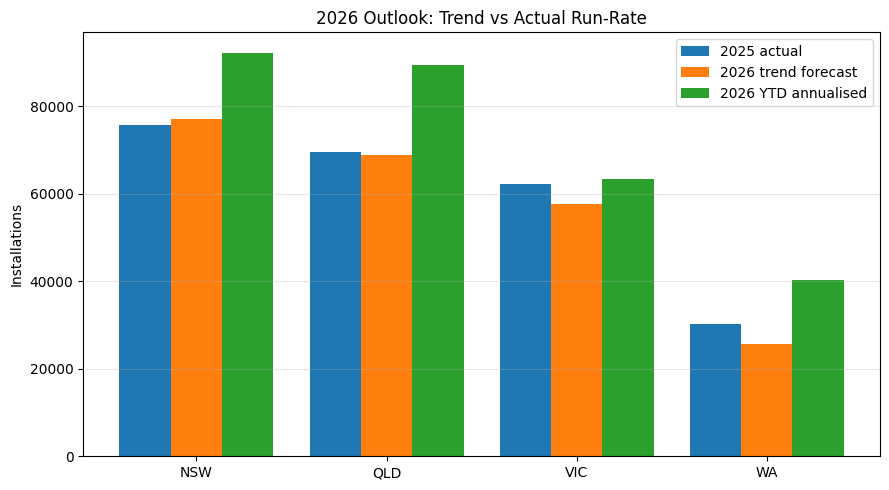

In [13]:
x = np.arange(len(forecast))
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 0.27, forecast['actual_2025'], width=0.27, label='2025 actual')
ax.bar(x,        forecast['trend_2026'], width=0.27, label='2026 trend forecast')
ax.bar(x + 0.27, forecast['annualised_2026'], width=0.27, label='2026 YTD annualised')
ax.set_xticks(x); ax.set_xticklabels(forecast['state'])
ax.set_ylabel('Installations'); ax.set_title('2026 Outlook: Trend vs Actual Run-Rate')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 13. Average system size (capacity ÷ installations)
Larger systems mean higher revenue per job. Compared 2015 vs 2025 (both full years).

In [14]:
cap_state = capacity.groupby(['state', 'year'])['capacity_kw'].sum()
inst_state = installs.groupby(['state', 'year'])['installs'].sum()
avg_size = (cap_state / inst_state).rename('avg_kw').reset_index()
avg_size = avg_size[avg_size['state'].isin(STATES)]

compare = avg_size[avg_size['year'].isin([2015, 2025])].pivot(index='state', columns='year', values='avg_kw').round(2)
compare['change_kw'] = (compare[2025] - compare[2015]).round(2)
compare.sort_values(2025, ascending=False)

year,2015,2025,change_kw
state,,,
NT,7.22,15.74,8.52
ACT,5.36,11.69,6.33
SA,5.52,11.23,5.71
NSW,5.27,10.74,5.47
QLD,4.88,10.73,5.85
TAS,4.72,9.82,5.10
VIC,4.78,9.38,4.60
WA,4.63,8.87,4.24


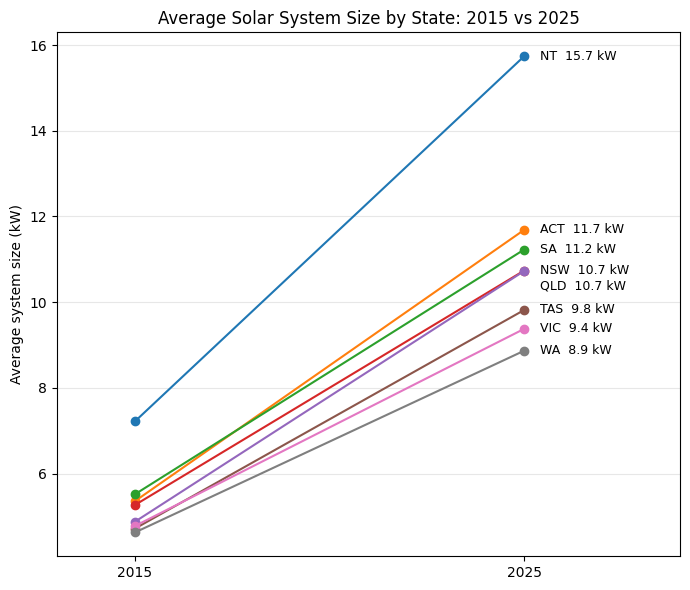

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
label_y = None
for s, r in compare.sort_values(2025, ascending=False).iterrows():
    ax.plot([0, 1], [r[2015], r[2025]], marker='o', linewidth=1.5)
    y = r[2025] if label_y is None else min(r[2025], label_y - 0.35)   # stop labels overlapping
    ax.text(1.04, y, f"{s}  {r[2025]:.1f} kW", va='center', fontsize=9)
    label_y = y
ax.set_xticks([0, 1]); ax.set_xticklabels(['2015', '2025'])
ax.set_xlim(-0.2, 1.4)
ax.set_ylabel('Average system size (kW)')
ax.set_title('Average Solar System Size by State: 2015 vs 2025')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 14. Findings and recommendation

**1. Core expansion priority: NSW, QLD, VIC and WA.** These four states accounted for 87% of 2025 installations. All four declined in 2025 (−8% to −23%), but their Jan–Aug 2026 run-rate is above 2025 levels in every case (VIC +2%, NSW +22%, QLD +29%, WA +33%), so the 2025 drop does not look structural.

**2. Lead with QLD and NSW.** They combine the largest volumes with strong 2026 rebounds. WA shows the fastest rebound but from roughly half the volume.

**3. NT, TAS and ACT are a secondary, niche play.** They were the most resilient markets in 2025 (NT the only state growing), but together represent under 4% of national volume. NT has the largest average systems (15.7 kW), which partly offsets its small volume through higher revenue per job.

**4. Revenue per installation is rising everywhere.** Average system size roughly doubled in every state between 2015 and 2025, so flat installation volumes still represent a growing market in kW terms.

**Recommendation:** focus expansion on QLD and NSW first, followed by WA and VIC, and treat NT/TAS/ACT as low-competition opportunities to test with a small footprint. The drivers of the 2025 dip and 2026 rebound (e.g. incentive changes) were not analysed here and should be investigated before committing capital.

## 15. Limitations
- **Postcode-to-state mapping:** state totals vary from CER Table 5 by <0.6%, likely due to cross-border postcodes.
- **Forecast:** linear trend uses only 5 points (R² shown per state); it is a baseline, not a prediction.
- **Annualisation:** assumes installations are spread evenly across months; seasonality is not adjusted for.
- **Recent data:** recent months may be revised as late registrations are processed (to verify on the CER page).
- **Volume ≠ opportunity:** installation counts do not capture competition, margins or customer demographics.